**Experiment 11: Construct and Analyze a Bayesian Network using pgmpy for Probabilistic Inference.**

**Aim:** To construct and analyze a **Bayesian Network** using the Python library **pgmpy** in order to model probabilistic relationships between variables and perform **probabilistic inference** using conditional dependencies.


**Overview of Bayesian Belief Network (BBN)**

A **Bayesian Belief Network (BBN)**, also called a **Bayesian Network**, is a **probabilistic graphical model** used to represent **uncertain relationships between variables** using probability theory.

In a BBN:

* Variables are represented as **nodes** in a graph.
* Relationships between variables are represented using **directed edges (arrows)**.
* Each variable has a **probability distribution** that defines how it depends on other variables.

The structure forms a **Directed Acyclic Graph (DAG)**, meaning the graph has **no cycles**.

BBNs are used for **probabilistic reasoning and inference under uncertainty**.

---

**Key Components**

**1. Random Variables (Nodes)**

Nodes represent the **variables of the system**.

X = {X1, X2, ..., Xn}

Each variable can represent a **random event or condition**.

---

**2. Directed Edges**

Directed edges represent **dependencies between variables**.

An edge from (Xi) to (Xj) means that **(Xj) depends on (Xi)**.

---

**3. Conditional Probability Distribution (CPD)**

Each node has a **Conditional Probability Distribution** that defines the probability of the node given its parent nodes.

P(Xi | Parents(Xi))

---

**4. Prior Probability**

If a node has **no parent nodes**, its probability is called **prior probability**.

P(Xi)

---

**5. Posterior Probability**

Posterior probability is the **updated probability of a variable after observing evidence**.

P(X | Evidence)

---

**Joint Probability Distribution**

A Bayesian Network represents the **joint probability distribution** of all variables.

P(X1, X2, ..., Xn) = product(P(Xi | Parents(Xi)))

---

**Model Representation**

A Bayesian Belief Network is represented as:

BBN = (G, P)

Where:

* **G** → Directed Acyclic Graph representing variable relationships
* **P** → Set of Conditional Probability Distributions

---

**Inference**

Inference is the process of **computing unknown probabilities using known evidence** in the network.

Common inference methods include:

* Variable Elimination
* Belief Propagation
* Sampling Methods


**Installation and Imports**

In [1]:
pip install pgmpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 27.1 MB/s eta 0:00:00


In [2]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination

In [3]:
# 1. Define the Network Structure (DAG)
# P = Pump, H = Heatwave, S = Shutdown, C = Cloud Failover, M = Maintenance Alert
model = DiscreteBayesianNetwork([
    ('P', 'S'),
    ('H', 'S'),
    ('S', 'C'),
    ('S', 'M')
])

# 2. Define Conditional Probability Tables (CPDs)
cpd_p = TabularCPD(variable='P', variable_card=2, values=[[0.995], [0.005]], state_names={'P': ['False', 'True']})
cpd_h = TabularCPD(variable='H', variable_card=2, values=[[0.98], [0.02]], state_names={'H': ['False', 'True']})

# S depends on P and H
cpd_s = TabularCPD(
    variable='S',
    variable_card=2,
    values=[[0.999, 0.60, 0.10, 0.01], # S=False
            [0.001, 0.40, 0.90, 0.99]], # S=True
    evidence=['P', 'H'],
    evidence_card=[2, 2],
    state_names={'S': ['False', 'True'], 'P': ['False', 'True'], 'H': ['False', 'True']}
)

# C and M depends only on S
cpd_c = TabularCPD(variable='C', variable_card=2, values=[[0.99, 0.08], [0.01, 0.92]], evidence=['S'], evidence_card=[2], state_names={'C': ['False', 'True'], 'S': ['False', 'True']})
cpd_m = TabularCPD(variable='M', variable_card=2, values=[[0.98, 0.15], [0.02, 0.85]], evidence=['S'], evidence_card=[2], state_names={'M': ['False', 'True'], 'S': ['False', 'True']})

# 3. Add CPDs to model and validate
model.add_cpds(cpd_p, cpd_h, cpd_s, cpd_c, cpd_m)
assert model.check_model()

# 4. Perform Probabilistic Inference
infer = VariableElimination(model)

# 5. Display CPDs
print("Conditional Probability Distributions (CPDs):")
for cpd in model.get_cpds():
    print(cpd)

Conditional Probability Distributions (CPDs):
+----------+-------+
| P(False) | 0.995 |
+----------+-------+
| P(True)  | 0.005 |
+----------+-------+
+----------+------+
| H(False) | 0.98 |
+----------+------+
| H(True)  | 0.02 |
+----------+------+
+----------+----------+----------+----------+---------+
| P        | P(False) | P(False) | P(True)  | P(True) |
+----------+----------+----------+----------+---------+
| H        | H(False) | H(True)  | H(False) | H(True) |
+----------+----------+----------+----------+---------+
| S(False) | 0.999    | 0.6      | 0.1      | 0.01    |
+----------+----------+----------+----------+---------+
| S(True)  | 0.001    | 0.4      | 0.9      | 0.99    |
+----------+----------+----------+----------+---------+
+----------+----------+---------+
| S        | S(False) | S(True) |
+----------+----------+---------+
| C(False) | 0.99     | 0.08    |
+----------+----------+---------+
| C(True)  | 0.01     | 0.92    |
+----------+----------+---------+
+------

**Model Validation and Network Information**

In [4]:
# Display model structure
print("Nodes in the Network:", model.nodes())
print("Edges in the Network:", model.edges())

# Check if the model is valid
print("Model is valid:", model.check_model())

Nodes in the Network: ['P', 'S', 'H', 'C', 'M']
Edges in the Network: [('P', 'S'), ('S', 'C'), ('S', 'M'), ('H', 'S')]
Model is valid: True


**Visualizing the Bayesian Network Structure**

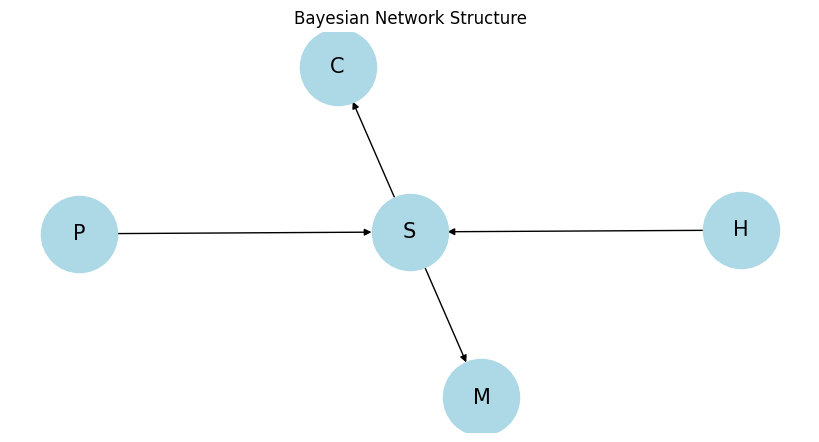

In [17]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph(model.edges())

plt.figure(figsize=(8,4))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=3000, node_color="lightblue", font_size=15)
plt.title("Bayesian Network Structure")
plt.show()

**Marginal Probability Queries**

Marginal probability calculates the probability of a variable without evidence.

In [6]:
# Probability of Shutdown
shutdown_prob = infer.query(variables=['S'])
print("Marginal Probability of Shutdown:")
print(shutdown_prob)

Marginal Probability of Shutdown:
+----------+----------+
| S        |   phi(S) |
+==========+==========+
| S(False) |   0.9866 |
+----------+----------+
| S(True)  |   0.0134 |
+----------+----------+


**Conditional Probability Queries**

**Query 1: Probability of Shutdown if Pump Failure occurs**

In [7]:
query1 = infer.query(variables=['S'], evidence={'P': 'True'})
print("Probability of Shutdown given Pump Failure:")
print(query1)

Probability of Shutdown given Pump Failure:
+----------+----------+
| S        |   phi(S) |
+==========+==========+
| S(False) |   0.0982 |
+----------+----------+
| S(True)  |   0.9018 |
+----------+----------+


**Query 2: Probability of Shutdown during Heatwave**

In [8]:
query2 = infer.query(variables=['S'], evidence={'H': 'True'})
print("Probability of Shutdown given Heatwave:")
print(query2)

Probability of Shutdown given Heatwave:
+----------+----------+
| S        |   phi(S) |
+==========+==========+
| S(False) |   0.5970 |
+----------+----------+
| S(True)  |   0.4030 |
+----------+----------+


**Joint Evidence Query**

**Query 3: Shutdown Probability when Pump Failure and Heatwave occur**

In [9]:
query3 = infer.query(variables=['S'], evidence={'P': 'True', 'H': 'True'})
print("Probability of Shutdown when Pump Failure and Heatwave occur:")
print(query3)

Probability of Shutdown when Pump Failure and Heatwave occur:
+----------+----------+
| S        |   phi(S) |
+==========+==========+
| S(False) |   0.0100 |
+----------+----------+
| S(True)  |   0.9900 |
+----------+----------+


**Reverse Inference (Diagnosis)**

**Query 4: Probability of Pump Failure given Cloud Failover and Maintenance Alert**

In [10]:
diagnosis = infer.query(variables=['P'], evidence={'C': 'True', 'M': 'True'})
print("Probability of Pump Failure given Cloud Failover and Maintenance Alert:")
print(diagnosis)

Probability of Pump Failure given Cloud Failover and Maintenance Alert:
+----------+----------+
| P        |   phi(P) |
+==========+==========+
| P(False) |   0.6708 |
+----------+----------+
| P(True)  |   0.3292 |
+----------+----------+


**Predictive Inference**

**Query 5: Probability of Maintenance Alert during Shutdown**

In [11]:
query5 = infer.query(variables=['M'], evidence={'S': 'True'})
print("Probability of Maintenance Alert during Shutdown:")
print(query5)

Probability of Maintenance Alert during Shutdown:
+----------+----------+
| M        |   phi(M) |
+==========+==========+
| M(False) |   0.1500 |
+----------+----------+
| M(True)  |   0.8500 |
+----------+----------+


**Multiple Variable Query**

**Query 6: Probabilities of Cloud Failover and Maintenance Alert given Pump Failure**

In [12]:
query6 = infer.query(variables=['C', 'M'], evidence={'P': 'True'})
print("Cloud Failover and Maintenance Alert given Pump Failure:")
print(query6)

Cloud Failover and Maintenance Alert given Pump Failure:
+----------+----------+------------+
| C        | M        |   phi(C,M) |
+==========+==========+============+
| C(False) | M(False) |     0.1061 |
+----------+----------+------------+
| C(False) | M(True)  |     0.0633 |
+----------+----------+------------+
| C(True)  | M(False) |     0.1254 |
+----------+----------+------------+
| C(True)  | M(True)  |     0.7052 |
+----------+----------+------------+


**Scenario Analysis**

Example: Heatwave occurs but pump is functioning normally

In [13]:
scenario = infer.query(variables=['S','C','M'], evidence={'P': 'False', 'H': 'True'})
print("System behavior during Heatwave with normal Pump:")
print(scenario)

System behavior during Heatwave with normal Pump:
+----------+----------+----------+--------------+
| S        | C        | M        |   phi(S,C,M) |
+==========+==========+==========+==============+
| S(False) | C(False) | M(False) |       0.5821 |
+----------+----------+----------+--------------+
| S(False) | C(False) | M(True)  |       0.0119 |
+----------+----------+----------+--------------+
| S(False) | C(True)  | M(False) |       0.0059 |
+----------+----------+----------+--------------+
| S(False) | C(True)  | M(True)  |       0.0001 |
+----------+----------+----------+--------------+
| S(True)  | C(False) | M(False) |       0.0048 |
+----------+----------+----------+--------------+
| S(True)  | C(False) | M(True)  |       0.0272 |
+----------+----------+----------+--------------+
| S(True)  | C(True)  | M(False) |       0.0552 |
+----------+----------+----------+--------------+
| S(True)  | C(True)  | M(True)  |       0.3128 |
+----------+----------+----------+--------------+


**Observations**

1. Pump failure significantly increases shutdown probability.

2. Heatwaves also increase shutdown risk but less than pump failure.

3. Shutdown strongly triggers cloud failover and maintenance alerts.

4. Observing C=True and M=True increases the likelihood of pump failure.

**Conclusion**

A **Bayesian Network model** was successfully constructed using **pgmpy**, CPDs were defined, and probabilistic inference was performed using multiple queries. The network demonstrated how dependencies among variables can be used to **predict outcomes and diagnose causes under uncertainty.**